In [1]:
import torch

x = torch.ones(5)  # input tensor
y = torch.zeros(3)  # expected output
w = torch.randn(5, 3, requires_grad=True)
b = torch.randn(3, requires_grad=True)
z = torch.matmul(x, w)+b
loss = torch.nn.functional.binary_cross_entropy_with_logits(z, y)

In [2]:
print(f"Gradient function for z = {z.grad_fn}")
print(f"Gradient function for loss = {loss.grad_fn}")

Gradient function for z = <AddBackward0 object at 0x10a45ea00>
Gradient function for loss = <BinaryCrossEntropyWithLogitsBackward0 object at 0x10a45e6d0>


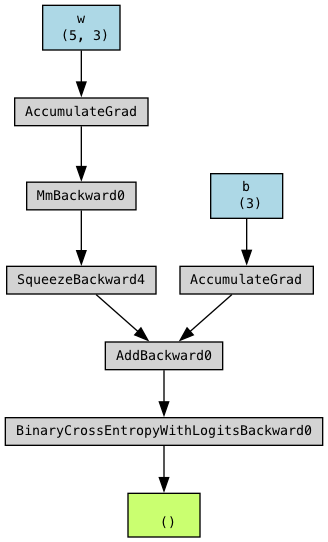

In [7]:
# 可视化计算图（需先安装: pip install torchviz，以及系统 graphviz: brew install graphviz）
from torchviz import make_dot
from IPython.display import Image, display

# 以 loss 为根节点画图，params 会把 w、b 标在图上
dot = make_dot(loss, params={"w": w, "b": b})
dot.render("04_pytorch_NN_graph", format="png", cleanup=True)  # 生成 04_pytorch_NN_graph.png
display(Image("04_pytorch_NN_graph.png"))

In [9]:
loss.backward()
print(w.grad)
print(b.grad)

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.